✅ Dataset loaded: 100 prompts
✅ Schema validation passed


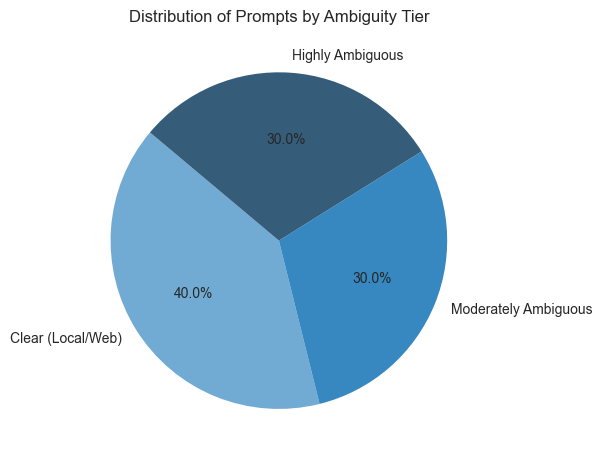

📊 Ground Truth × Ambiguity Tier:
                    Clear (Local/Web)  Moderately Ambiguous  Highly Ambiguous
ground_truth                                                                 
Local (Historical)                 20                    19                13
Web (Real-time)                    20                    11                17


/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_80449/3905594677.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tags_df, x="tag", y="count", palette="Greens_d")


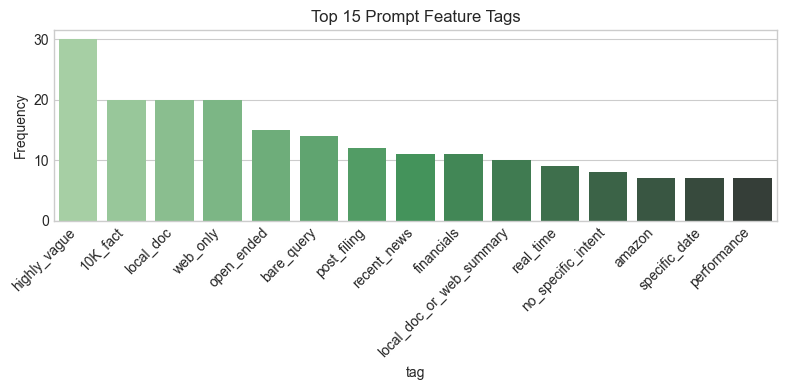


🔍 Tier 1 (Clear (Local/Web)):
  • ID: 40 | GT: local
    "What was Pinterest's global monthly active user count as reported in its FY2025 annual filing?"
    Tags: ['pinterest', 'monthly_active_users', '10K_fact', 'platform_metrics', 'local_doc']
------------------------------------------------------------
  • ID: 37 | GT: local
    "What were IBM's total revenues for fiscal year 2025 as reported in its annual filing?"
    Tags: ['ibm', 'total_revenue', '10K_fact', 'financials', 'local_doc']
------------------------------------------------------------

🔍 Tier 2 (Moderately Ambiguous):
  • ID: 78 | GT: local
    "How does HP Inc. split its revenue between the personal systems and printing segments?"
    Tags: ['hp', 'segment_revenue', 'personal_systems', 'local_doc_or_web_summary', 'printing']
------------------------------------------------------------
  • ID: 66 | GT: web
    "How does Visa's global payment network compare to Mastercard's in terms of transaction volume and market sha

In [3]:
# Cell 1 [Markdown]
# # 📊 Dataset Exploration & Ambiguity Validation
# This notebook validates the prompt dataset schema, explores ambiguity tier distribution, 
# analyzes prompt feature tags, and provides qualitative examples for each tier.
 
# Cell 2 [Code]
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")
 
# Paths
DATA_DIR = Path("../data/dataset")
PROMPT_PATH = DATA_DIR / "prompts_dataset.json"
 
# Load dataset
with open(PROMPT_PATH, "r") as f:
    raw_data = json.load(f)
 
df_prompts = pd.DataFrame(raw_data)
 
# Handle list column (prompt_tags)
if df_prompts["prompt_tags"].dtype == "object":
    df_prompts["prompt_tags"] = df_prompts["prompt_tags"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
 
print(f"✅ Dataset loaded: {len(df_prompts)} prompts")
df_prompts.head()
 
# Cell 3 [Code]
# Schema Validation
required_cols = {"query_id", "prompt", "ambiguity_tier", "ground_truth", "prompt_tags"}
missing = required_cols - set(df_prompts.columns)
assert len(missing) == 0, f"Missing columns: {missing}"
 
assert df_prompts["ambiguity_tier"].isin([1, 2, 3]).all(), "Invalid ambiguity_tier values"
assert df_prompts["ground_truth"].isin(["local", "web", "uncertain"]).all(), "Invalid ground_truth values"
print("✅ Schema validation passed")
 
# Cell 4 [Code]
# Distribution of Ambiguity Tiers
tier_counts = df_prompts["ambiguity_tier"].value_counts().sort_index()
tier_labels = {1: "Clear (Local/Web)", 2: "Moderately Ambiguous", 3: "Highly Ambiguous"}
 
# plt.figure(figsize=(6, 4))
# sns.barplot(x=tier_counts.index.map(tier_labels), y=tier_counts.values, palette="Blues_d")
# plt.title("Distribution of Prompts by Ambiguity Tier")
# plt.ylabel("Number of Prompts")
# plt.xlabel("Ambiguity Level")
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(6, 6))
plt.pie(
    tier_counts.values,
    labels=tier_counts.index.map(tier_labels),
    autopct="%1.1f%%",
    colors=sns.color_palette("Blues_d", len(tier_counts)),
    startangle=140
)
plt.title("Distribution of Prompts by Ambiguity Tier")
plt.tight_layout()
plt.show()
 
# Cell 5 [Code]
# Ground Truth vs Ambiguity Tier Cross-Tab
ct = pd.crosstab(df_prompts["ground_truth"], df_prompts["ambiguity_tier"])
ct.index = ct.index.map({"local": "Local (Historical)", "web": "Web (Real-time)", "uncertain": "Ambiguous"})
ct.columns = [tier_labels[i] for i in ct.columns]
print("📊 Ground Truth × Ambiguity Tier:")
print(ct)
 
# Cell 6 [Code]
# Prompt Tag Frequency Analysis
from collections import Counter
all_tags = [tag for sublist in df_prompts["prompt_tags"] for tag in sublist]
tag_counts = Counter(all_tags).most_common(15)
 
tags_df = pd.DataFrame(tag_counts, columns=["tag", "count"])
plt.figure(figsize=(8, 4))
sns.barplot(data=tags_df, x="tag", y="count", palette="Greens_d")
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Prompt Feature Tags")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
 
# Cell 7 [Code]
# Sample Prompts per Tier
for tier in [1, 2, 3]:
    sample = df_prompts[df_prompts["ambiguity_tier"] == tier].sample(2, random_state=42)
    print(f"\n🔍 Tier {tier} ({tier_labels[tier]}):")
    for _, row in sample.iterrows():
        print(f"  • ID: {row['query_id']} | GT: {row['ground_truth']}")
        print(f"    \"{row['prompt']}\"")
        print(f"    Tags: {row['prompt_tags']}")
        print("-" * 60)